In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)

plt.rcParams["figure.figsize"]=(10,6)
plt.rcParams["figure.dpi"]=140
plt.rcParams["savefig.dpi"]=300
plt.rcParams["axes.titleweight"]="bold"
plt.rcParams["axes.labelweight"]="bold"

In [3]:
BASE_DIR = Path("../")

REPORT_DIR = BASE_DIR/"reports"

REPORT_DIR.mkdir(exist_ok=True)

In [4]:
data = pd.read_csv("../data/HR_Employee_Attrition.csv")

data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print("="*60)

print("Dataset Shape")

print("="*60)

print(data.shape)

print()

print(data.info())

print()

print(data.describe().T)

Dataset Shape
(1470, 35)

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                 

                           count          mean          std     min      25%  \
Age                       1470.0     36.923810     9.135373    18.0    30.00   
DailyRate                 1470.0    802.485714   403.509100   102.0   465.00   
DistanceFromHome          1470.0      9.192517     8.106864     1.0     2.00   
Education                 1470.0      2.912925     1.024165     1.0     2.00   
EmployeeCount             1470.0      1.000000     0.000000     1.0     1.00   
EmployeeNumber            1470.0   1024.865306   602.024335     1.0   491.25   
EnvironmentSatisfaction   1470.0      2.721769     1.093082     1.0     2.00   
HourlyRate                1470.0     65.891156    20.329428    30.0    48.00   
JobInvolvement            1470.0      2.729932     0.711561     1.0     2.00   
JobLevel                  1470.0      2.063946     1.106940     1.0     1.00   
JobSatisfaction           1470.0      2.728571     1.102846     1.0     2.00   
MonthlyIncome             1470.0   6502.

In [6]:
missing=data.isnull().sum()

missing=missing[missing>0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

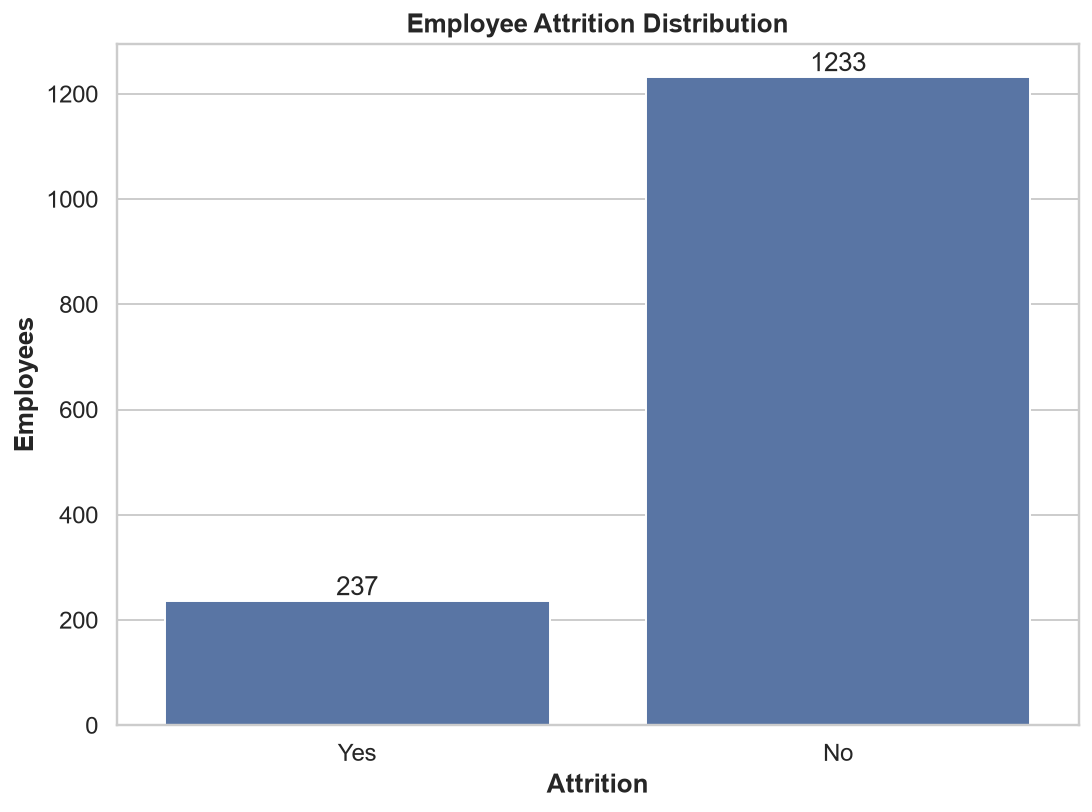

In [7]:
plt.figure(figsize=(8,6))

ax=sns.countplot(
    data=data,
    x="Attrition"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Employee Attrition Distribution")

plt.xlabel("Attrition")

plt.ylabel("Employees")

plt.tight_layout()

plt.savefig("../reports/01_attrition_distribution.png")

plt.show()

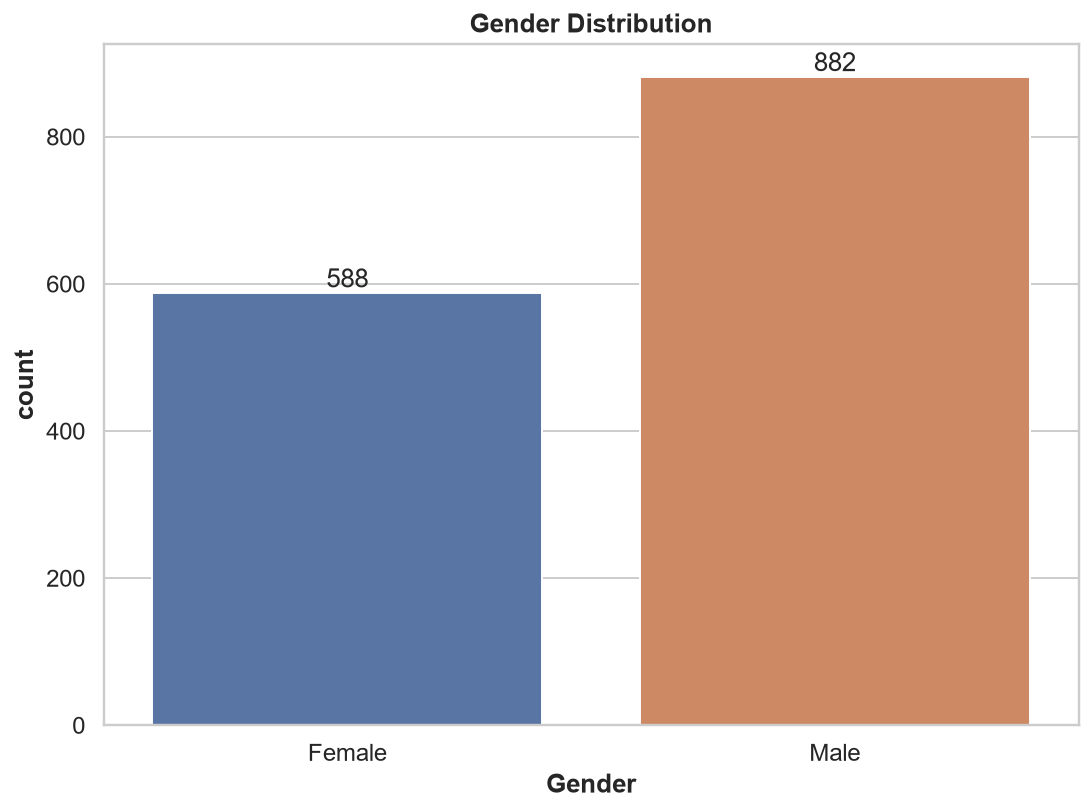

In [8]:
plt.figure(figsize=(8,6))

ax=sns.countplot(
    data=data,
    x="Gender",
    hue="Gender",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution")

plt.tight_layout()

plt.savefig("../reports/02_gender_distribution.png")

plt.show()

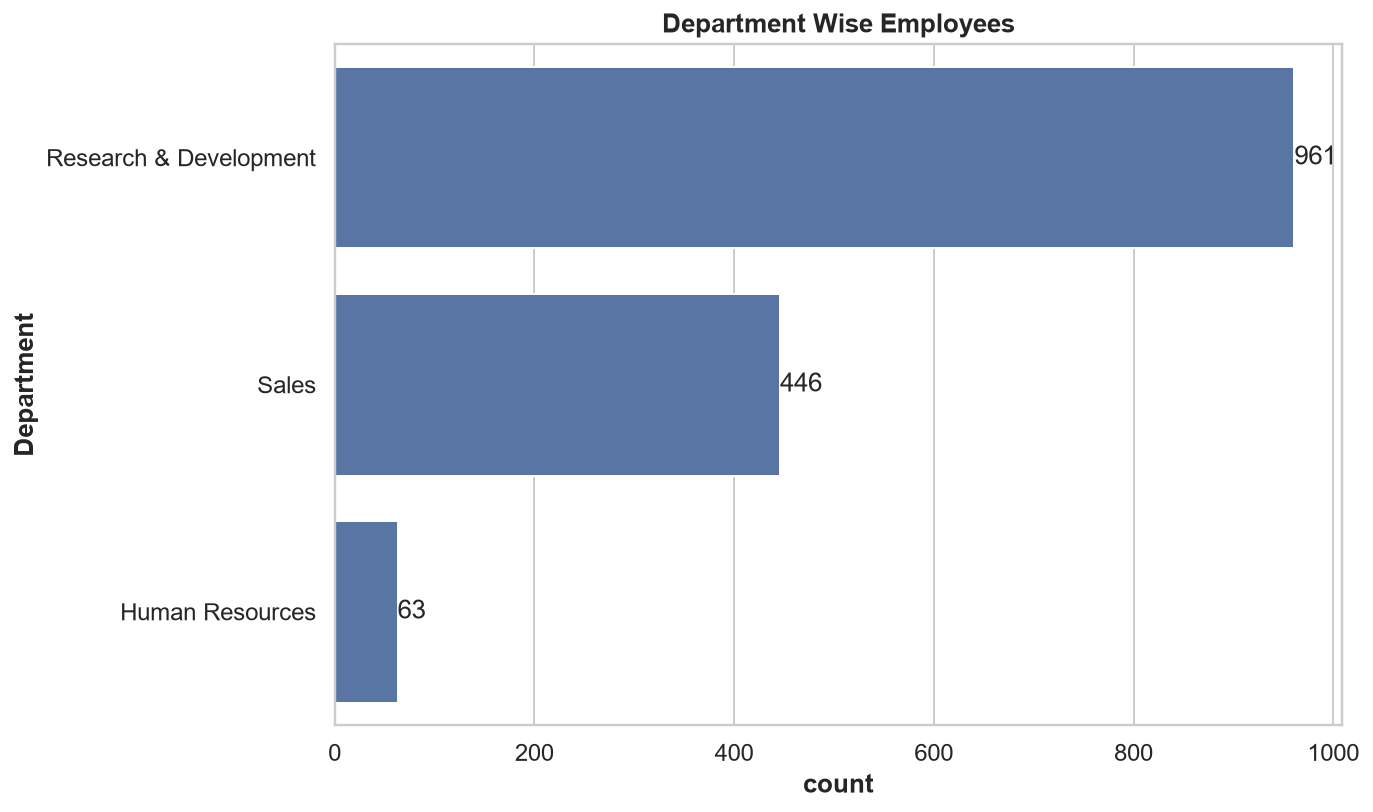

In [9]:
plt.figure(figsize=(10,6))

ax=sns.countplot(
    data=data,
    y="Department",
    order=data["Department"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Department Wise Employees")

plt.tight_layout()

plt.savefig("../reports/03_department_distribution.png")

plt.show()

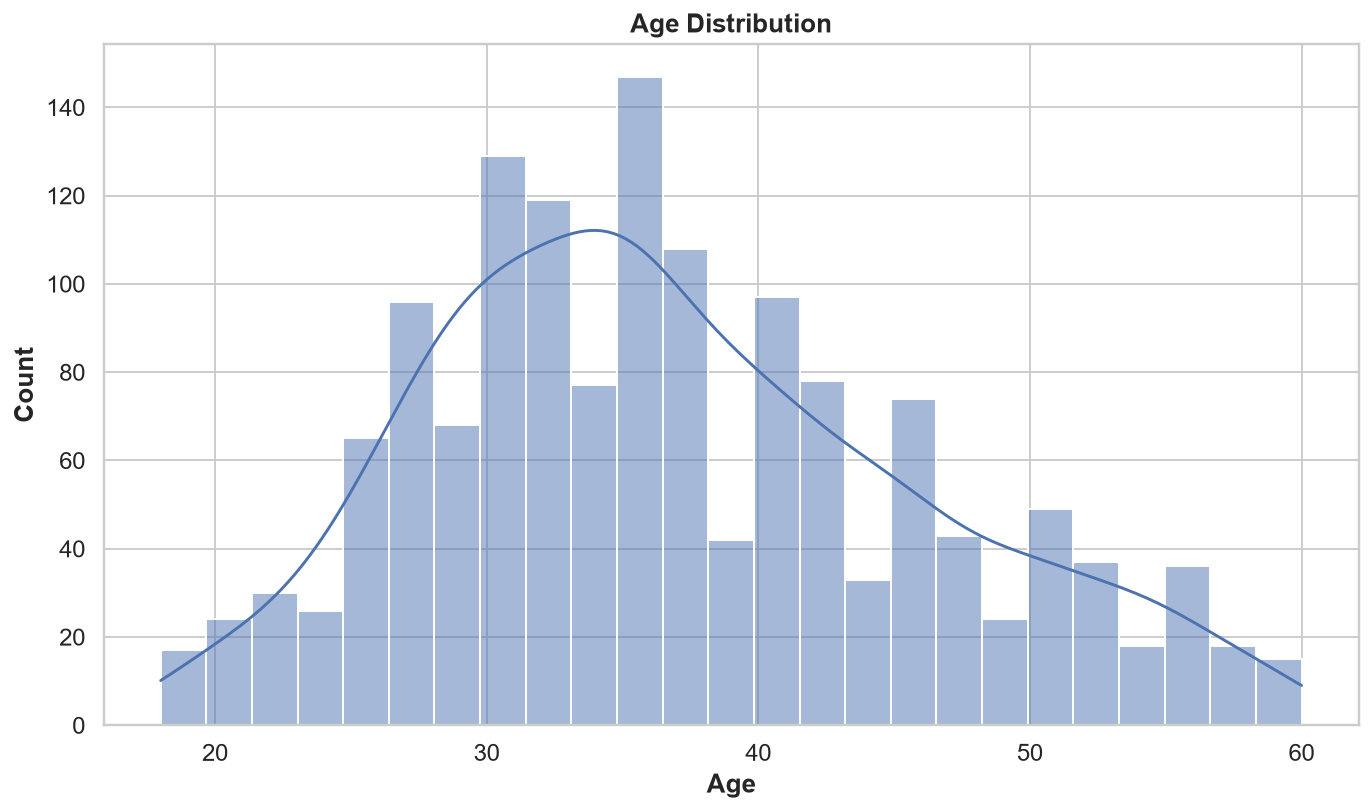

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    data["Age"],
    kde=True,
    bins=25
)

plt.title("Age Distribution")

plt.tight_layout()

plt.savefig("../reports/04_age_distribution.png")

plt.show()

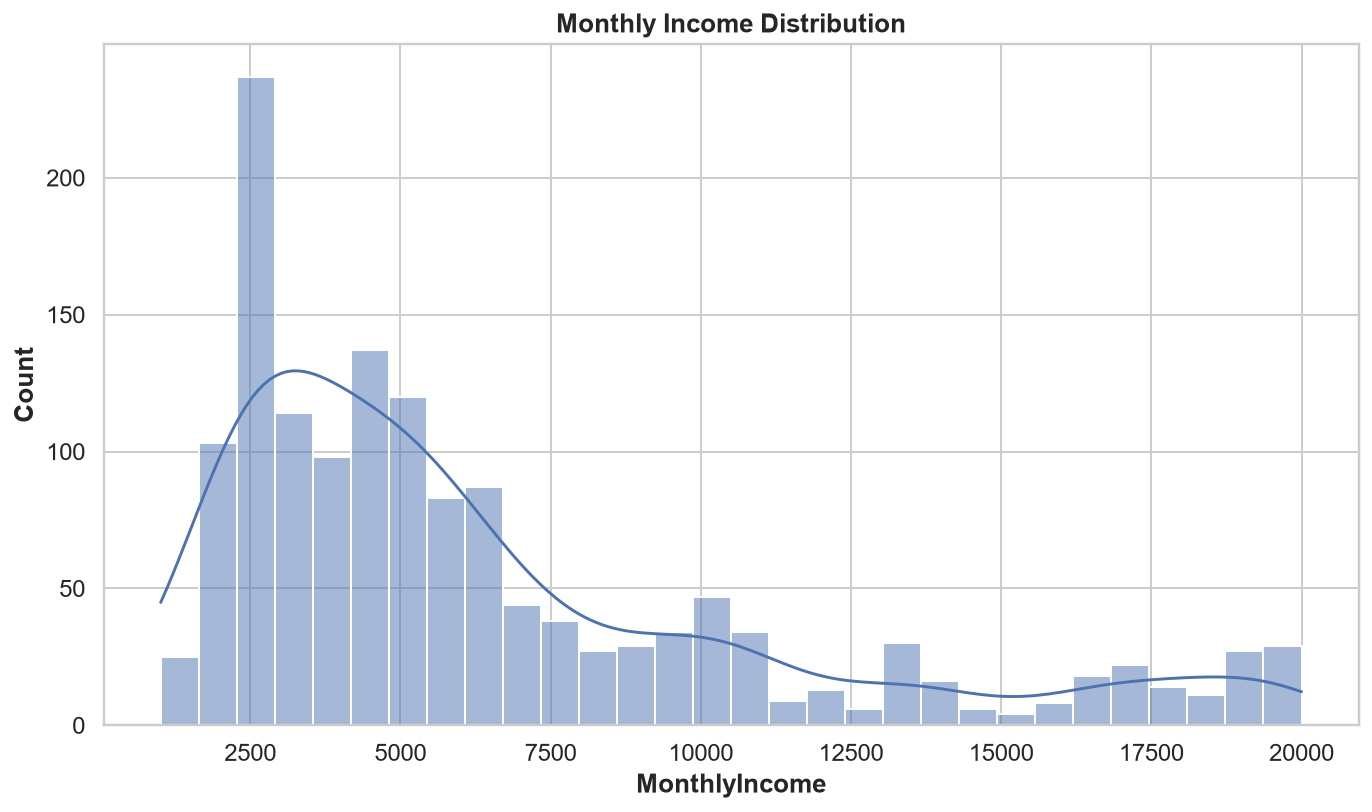

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    data["MonthlyIncome"],
    bins=30,
    kde=True
)

plt.title("Monthly Income Distribution")

plt.tight_layout()

plt.savefig("../reports/05_monthly_income_distribution.png")

plt.show()

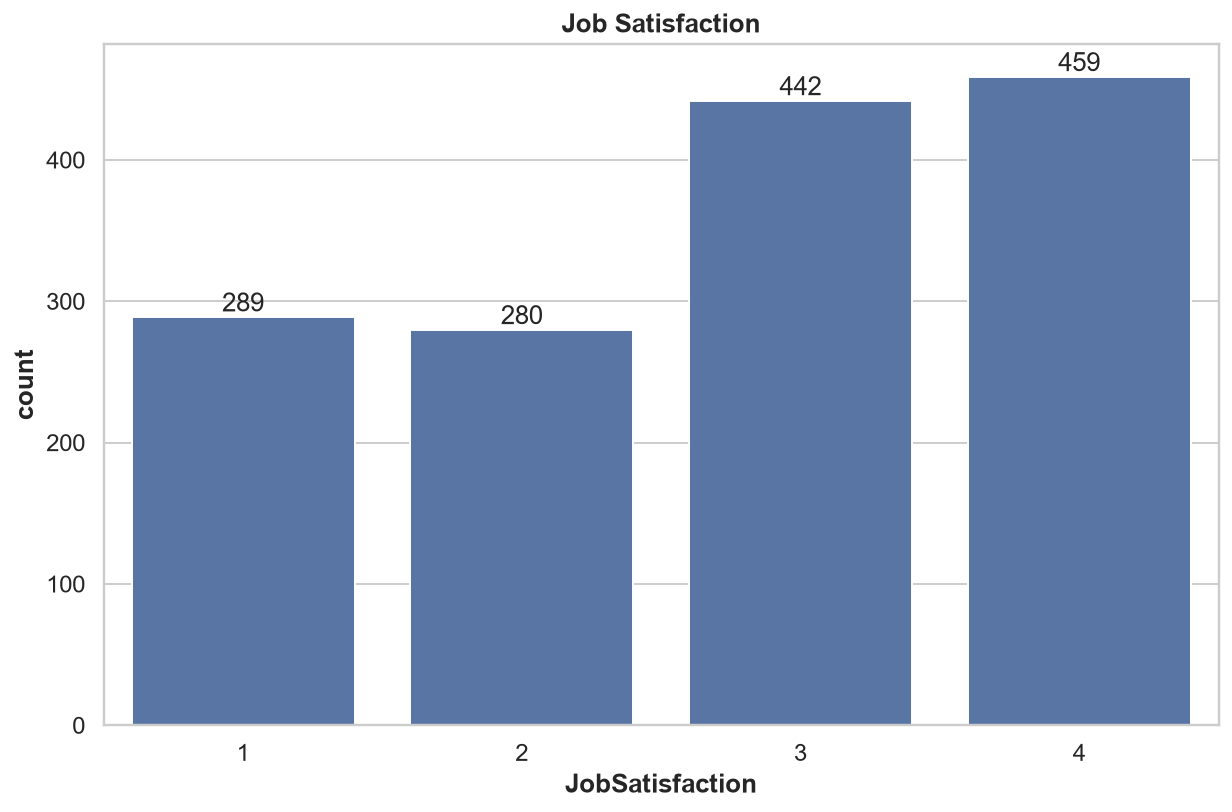

In [12]:
plt.figure(figsize=(9,6))

ax=sns.countplot(
    data=data,
    x="JobSatisfaction"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Job Satisfaction")

plt.tight_layout()

plt.savefig("../reports/06_job_satisfaction.png")

plt.show()

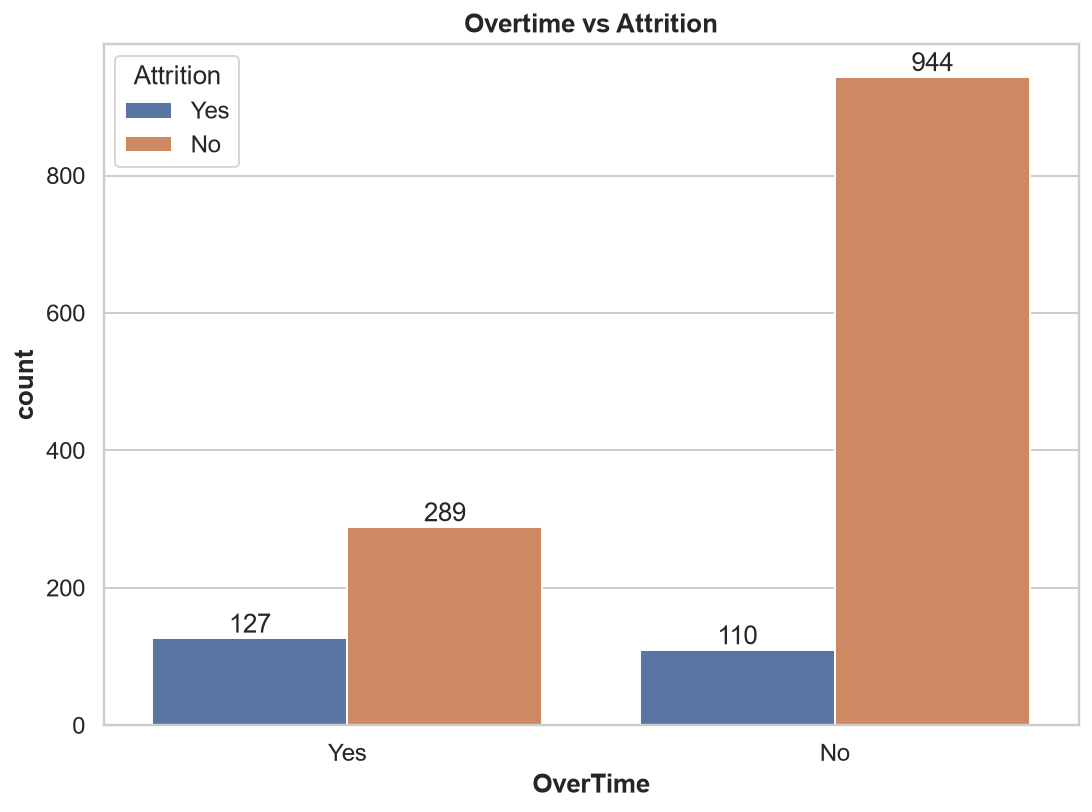

In [13]:
plt.figure(figsize=(8,6))

ax=sns.countplot(
    data=data,
    x="OverTime",
    hue="Attrition"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Overtime vs Attrition")

plt.tight_layout()

plt.savefig("../reports/07_overtime_vs_attrition.png")

plt.show()

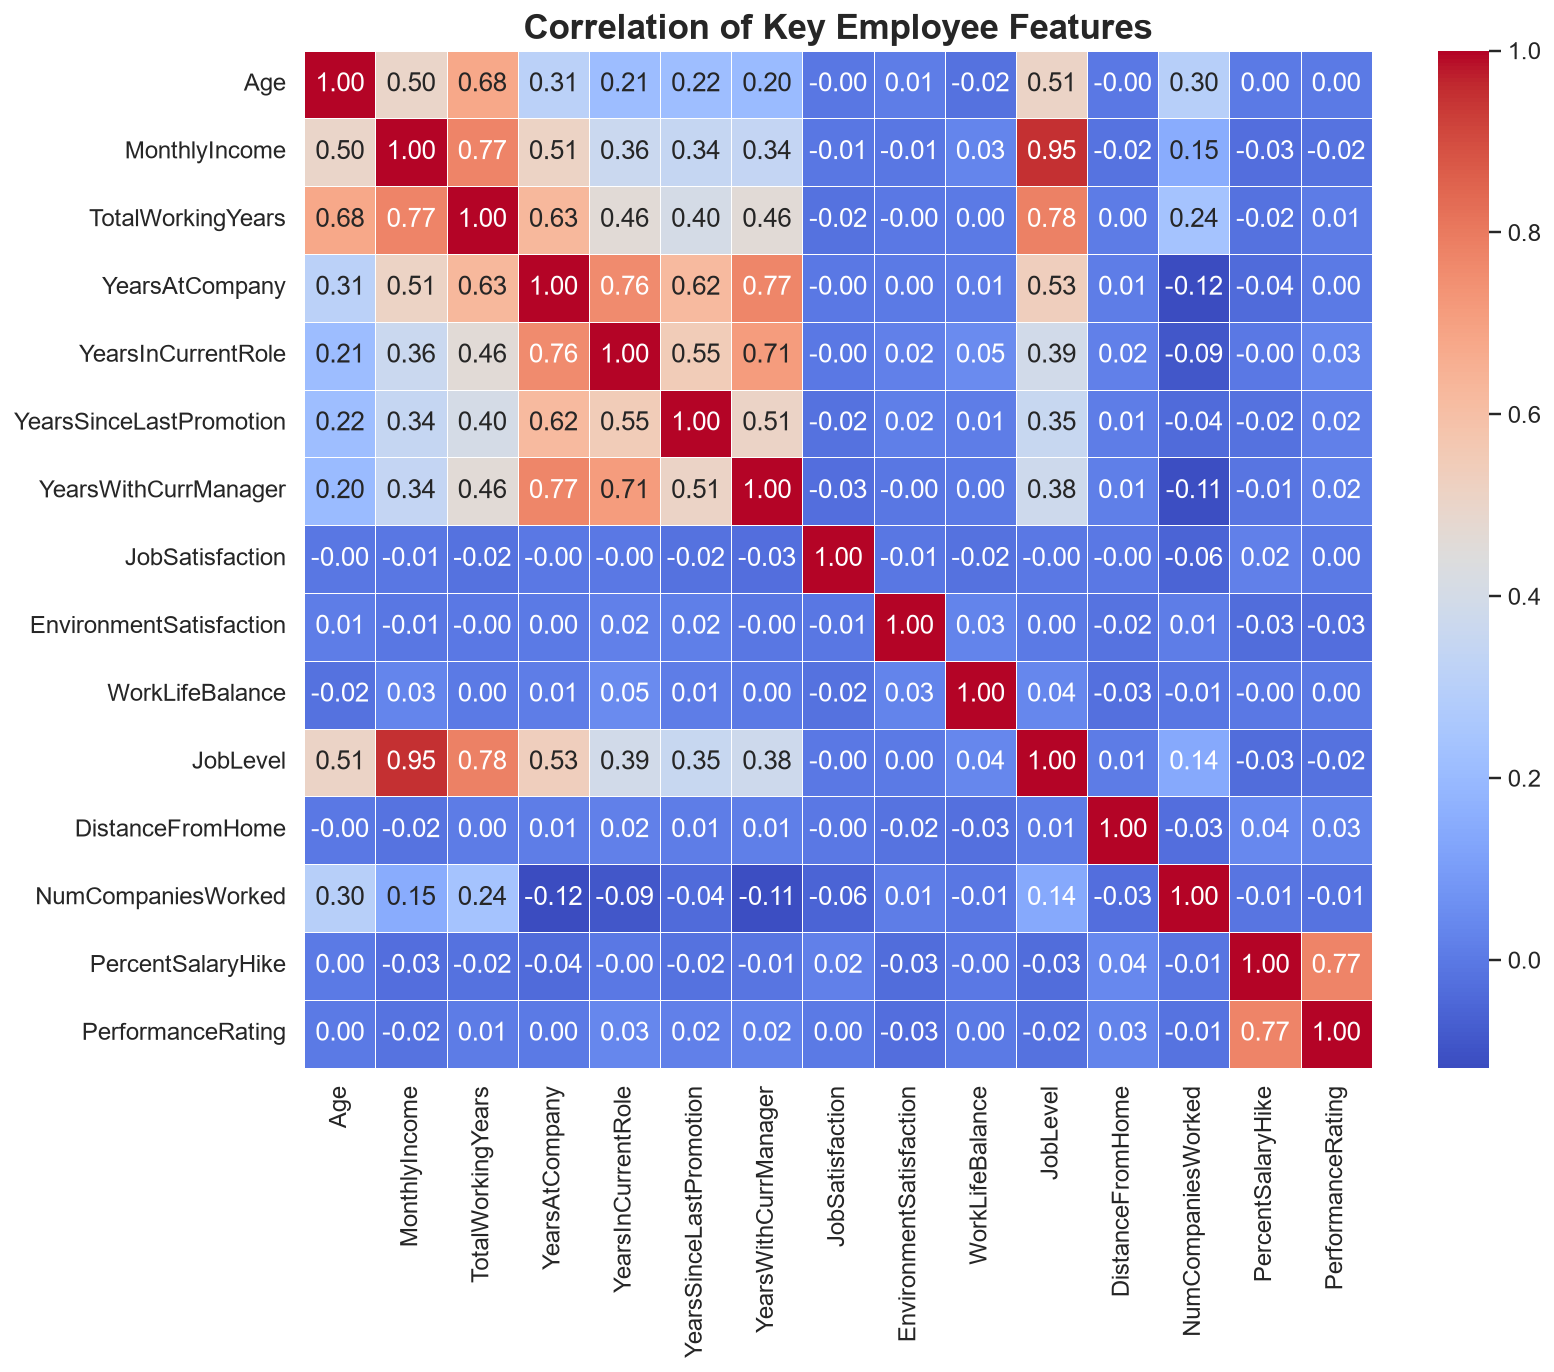

In [20]:
top_features = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "JobLevel",
    "DistanceFromHome",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "PerformanceRating"
]

corr = data[top_features].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=.5
)

plt.title(
    "Correlation of Key Employee Features",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.savefig("../reports/08_correlation_heatmap.png", dpi=300)

plt.show()

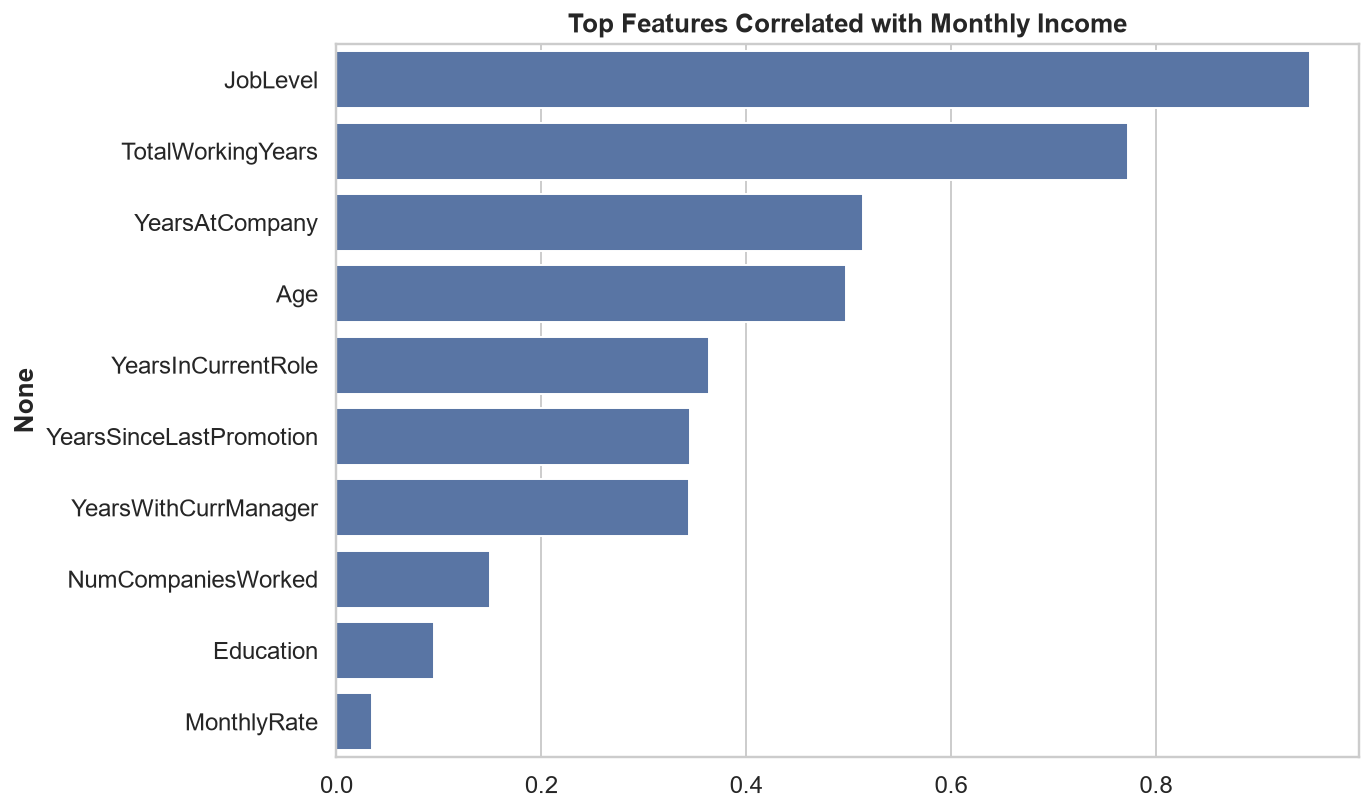

In [15]:
corr=numeric.corr()["MonthlyIncome"]

corr=corr.abs().sort_values(ascending=False)[1:11]

plt.figure(figsize=(10,6))

sns.barplot(
    x=corr.values,
    y=corr.index
)

plt.title("Top Features Correlated with Monthly Income")

plt.tight_layout()

plt.savefig("../reports/09_top_feature_correlation.png")

plt.show()

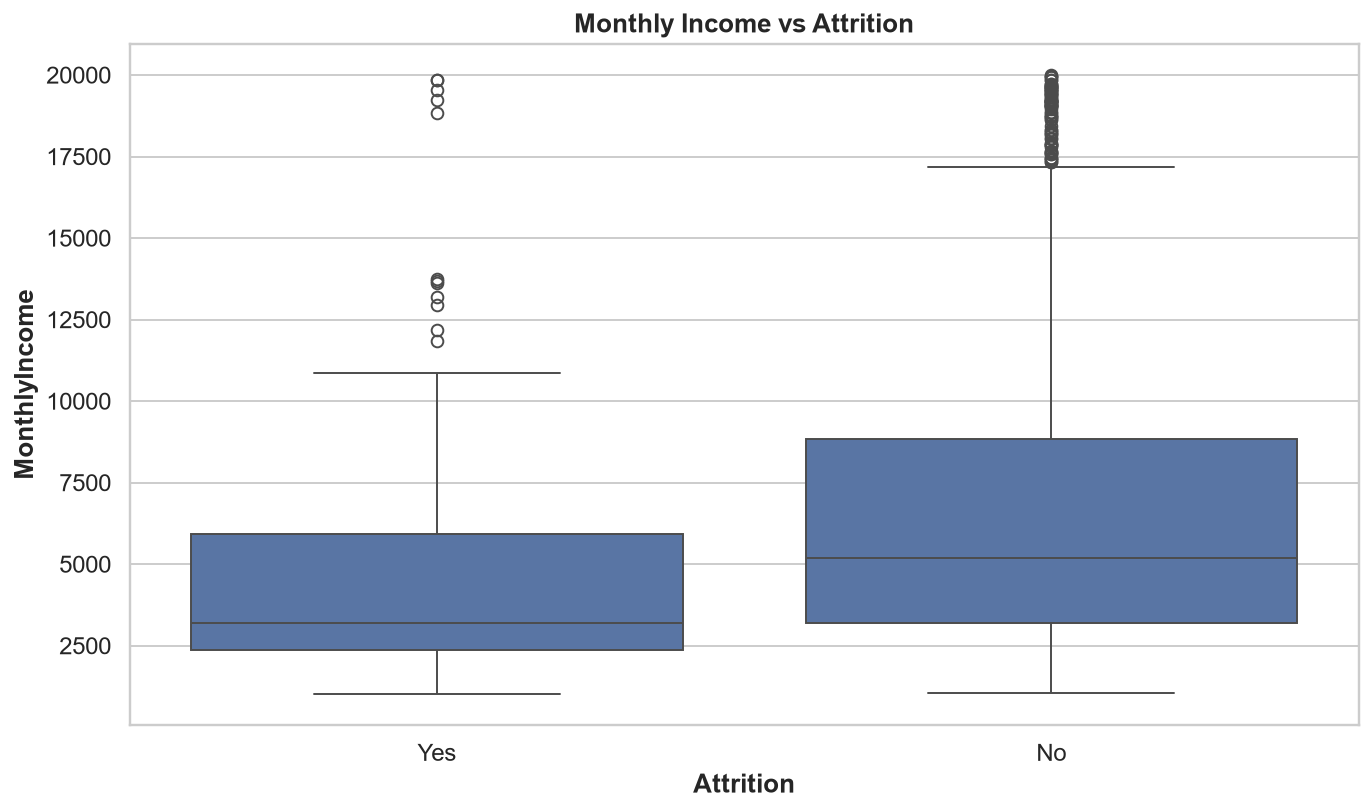

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=data,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")

plt.tight_layout()

plt.savefig("../reports/10_boxplot_income_attrition.png")

plt.show()

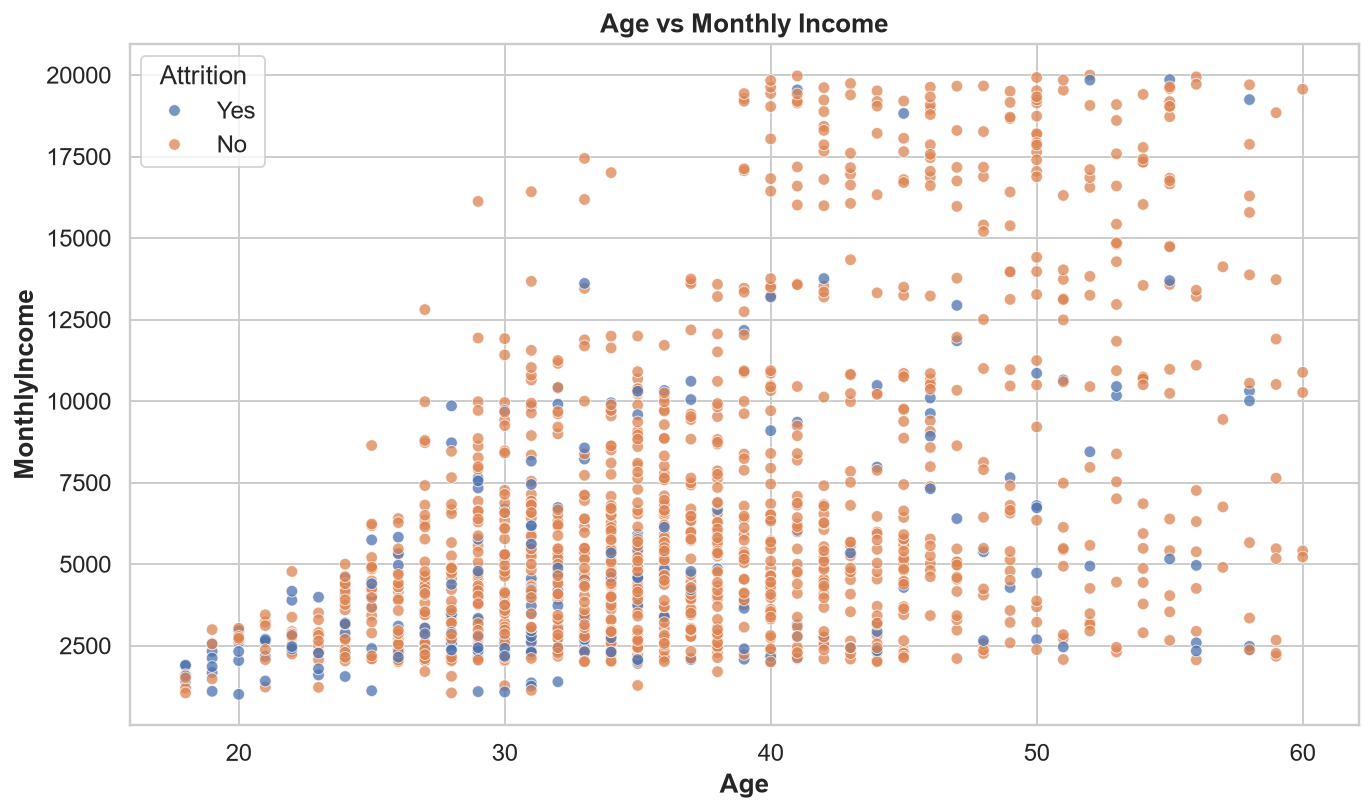

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x="Age",
    y="MonthlyIncome",
    hue="Attrition",
    alpha=.75
)

plt.title("Age vs Monthly Income")

plt.tight_layout()

plt.savefig("../reports/11_age_vs_income.png")

plt.show()

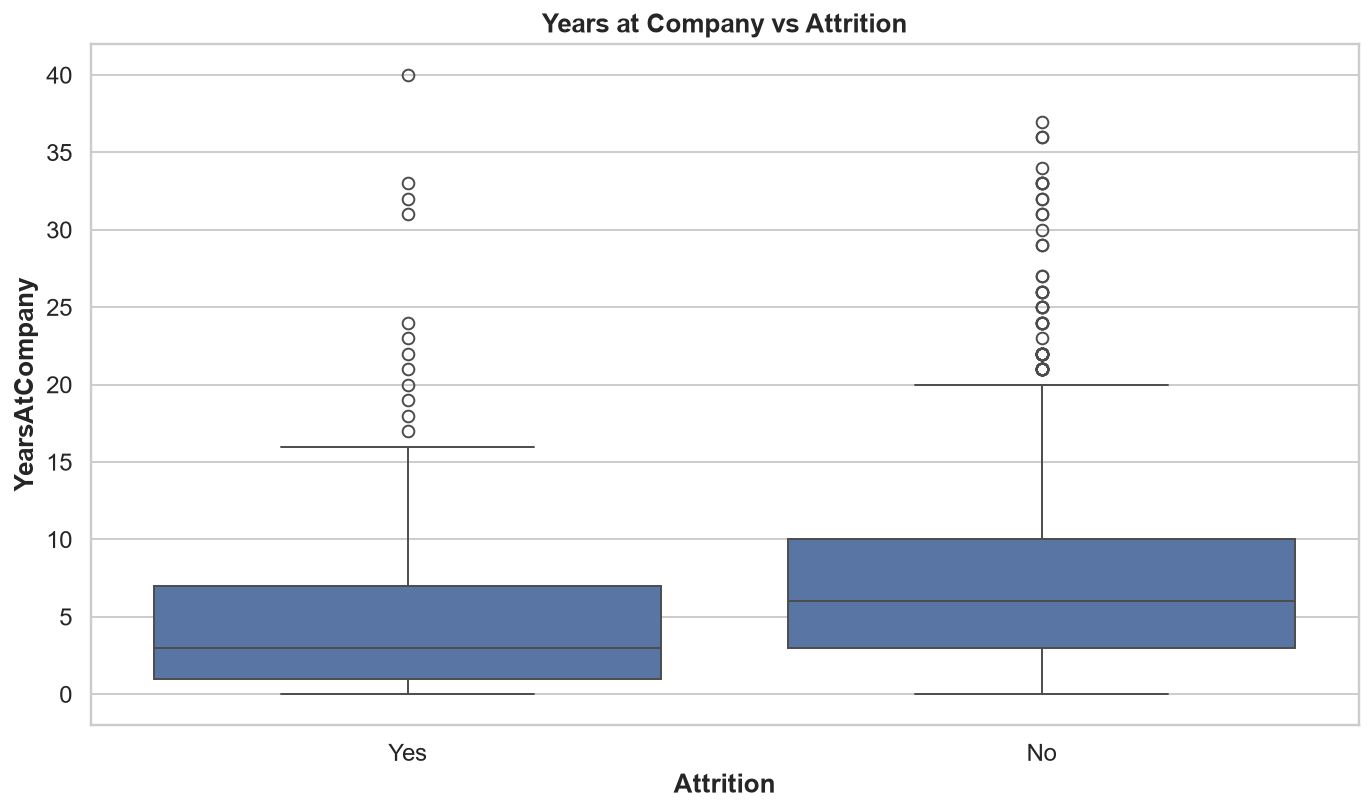

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=data,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Attrition")

plt.tight_layout()

plt.savefig("../reports/12_years_company_attrition.png")

plt.show()